In [372]:
import pandas as pd
import numpy as np

In [373]:
df = pd.read_csv('laptop_data.csv')

In [374]:
df.sample(5)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
382,382,Asus,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.3kg,88178.40
197,197,HP,Notebook,13.3,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,512GB SSD,Intel UHD Graphics 620,Windows 10,1.49kg,51095.52
471,471,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,500GB HDD,AMD FirePro W4190M,Windows 10,1.9kg,61485.12
29,29,HP,Notebook,17.3,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.5kg,47738.88
276,276,Dell,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,128GB SSD + 1TB HDD,AMD Radeon 530,Linux,2.8kg,58554.72


In [375]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [376]:
print(f"rows : {df.shape[0]} columns : {df.shape[1]}")

rows : 1303 columns : 12


In [377]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [378]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [379]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [380]:
df.duplicated().sum()

0

In [381]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [382]:
# drop the columns Unnamed:0
df.drop(columns=['Unnamed: 0'],inplace=True)

In [383]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
692,HP,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,500GB HDD,Nvidia Quadro M1200,Windows 10,3.14kg,101657.7072
666,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.06kg,50882.4000
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
534,Asus,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.3kg,87858.7200
435,Asus,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,90309.6000


In [384]:
# remove gb form ram and convert it into integer
df["Ram"] = df["Ram"].str.replace('GB',"").astype(int)

In [385]:
df["Ram"].info()
df

<class 'pandas.core.series.Series'>
RangeIndex: 1303 entries, 0 to 1302
Series name: Ram
Non-Null Count  Dtype
--------------  -----
1303 non-null   int32
dtypes: int32(1)
memory usage: 5.2 KB


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [386]:
# remove kg from weight and convert it into float
df["Weight"] = df["Weight"].str.replace("kg","").astype(float)

In [387]:
df["Weight"].info()
df

<class 'pandas.core.series.Series'>
RangeIndex: 1303 entries, 0 to 1302
Series name: Weight
Non-Null Count  Dtype  
--------------  -----  
1303 non-null   float64
dtypes: float64(1)
memory usage: 10.3 KB


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200


In [388]:
# convert price to integer
df["Price"] = df["Price"].astype(int)

In [389]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705


In [390]:
df["OpSys"].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

C:\Users\piyus\AppData\Local\Temp\ipykernel_3960\106281001.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Price"])


<Axes: xlabel='Price', ylabel='Density'>

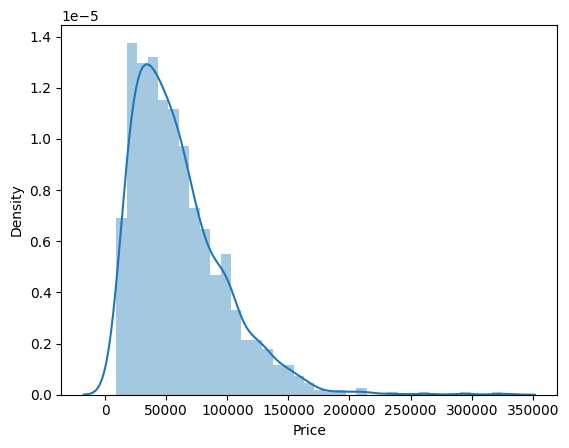

In [391]:
import seaborn as sns
sns.distplot(df["Price"])

<Axes: xlabel='Company'>

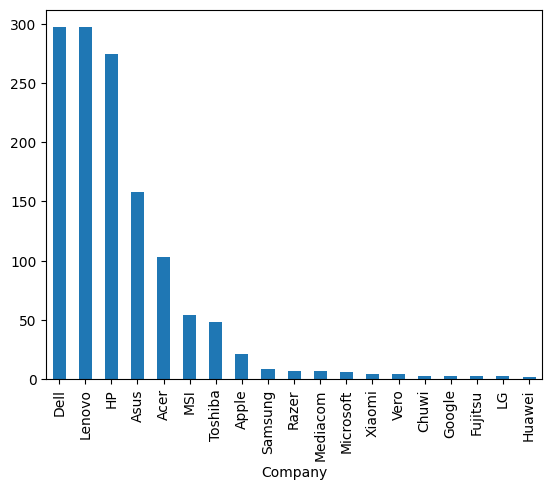

In [392]:
df["Company"].value_counts().plot(kind="bar")

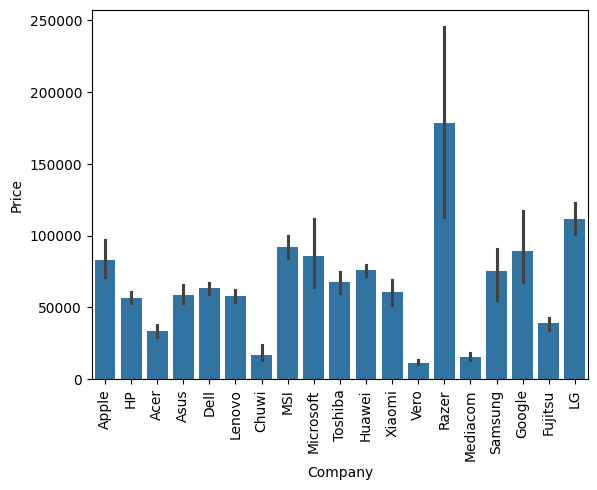

In [393]:
import matplotlib.pyplot as plt
sns.barplot(x=df["Company"],y=df["Price"])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

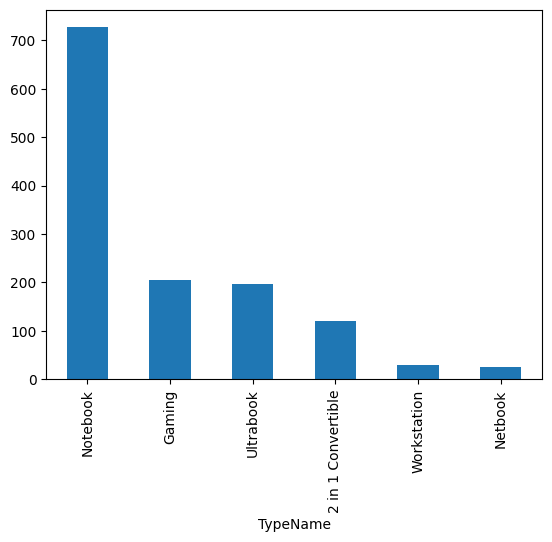

In [394]:
df["TypeName"].value_counts().plot(kind="bar")

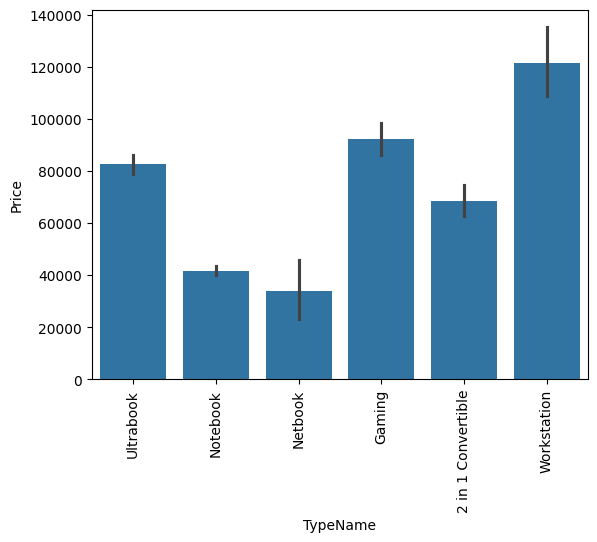

In [395]:
sns.barplot(x=df["TypeName"],y=df["Price"])
plt.xticks(rotation='vertical')
plt.show()

In [396]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [397]:
df["Touchscreen"] = df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in x else 0)

In [398]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
747,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.86,28717,0
571,HP,Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8,2TB HDD,Intel HD Graphics 405,Windows 10,1.94,20725,0
804,Dell,Netbook,11.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4,128GB SSD,Intel HD Graphics 505,Windows 10,1.63,39640,0
1221,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.20,78647,0
774,HP,Ultrabook,12.5,1366x768,Intel Core i5 6200U 2.3GHz,4,256GB SSD,Intel HD Graphics 520,Windows 10,1.26,66280,0


In [399]:
# check if the laptops has ips panel or not
df["IPS"] = df['ScreenResolution'].apply(lambda x: 1 if "IPS Panel" in x else 0)

In [400]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS
909,LG,Ultrabook,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,8,512GB SSD,Intel HD Graphics 620,Windows 10,0.98,101178,1,1
198,HP,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,3.35,73473,0,1
228,Asus,Notebook,17.3,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD + 500GB HDD,Nvidia GeForce GTX 950M,Windows 10,2.69,47472,0,0
1001,HP,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.34,63349,0,1
404,MSI,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.80,119826,0,0


In [401]:
# create a xresolution and yresolution columns 
new = df["ScreenResolution"].str.split("x",expand=True)

In [402]:
df["x_res"] = new[0]
df["y_res"] = new[1]

In [403]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,x_res,y_res
395,HP,Ultrabook,15.6,Full HD 1920x1080,AMD A9-Series 9420 3GHz,4,256GB SSD,AMD Radeon 520,Windows 10,1.91,26586,0,0,Full HD 1920,1080
1212,MSI,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.43,103842,0,1,IPS Panel Full HD 1920,1080
606,Toshiba,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,2.20,74538,0,1,IPS Panel Full HD 1920,1080
1009,HP,Notebook,14.0,1366x768,Intel Core i3 7100U 2.4GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,1.64,36443,0,0,1366,768
1177,Lenovo,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16,512GB SSD,Nvidia GeForce GTX 960,Windows 10,3.31,69530,0,1,IPS Panel Full HD 1920,1080


In [404]:
df["x_res"] = df["x_res"].str.split(" ").str[-1]

In [405]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,x_res,y_res
285,Acer,Notebook,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,12,1TB HDD,Intel HD Graphics 620,Windows 10,2.15,35111,1,1,1920,1080
704,Lenovo,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4,500GB HDD,Intel HD Graphics 520,No OS,1.90,23976,0,0,1366,768
1044,HP,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4,500GB HDD,Intel HD Graphics 520,Windows 10,1.54,53280,0,0,1920,1080
591,Lenovo,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,12,512GB SSD,AMD Radeon 530,Windows 10,2.20,50562,0,0,1920,1080
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512GB SSD,AMD Radeon Pro 560,macOS,1.83,152274,0,1,2880,1800


In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   int32  
 11  Touchscreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  x_res             1303 non-null   object 
 14  y_res             1303 non-null   object 
dtypes: float64(2), int32(2), int64(2), object(9)
memory usage: 142.6+ KB


In [407]:
df["x_res"] = df["x_res"].astype(int)
df["y_res"] = df["y_res"].astype(int)

In [408]:
# doing feature construction by combining the Inches and x_res and y_res columns
df["ppi"] = (((df["x_res"]**2 + df["y_res"]**2))**0.5/df['Inches']).astype(float)

In [409]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,x_res,y_res,ppi
591,Lenovo,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,12,512GB SSD,AMD Radeon 530,Windows 10,2.20,50562,0,0,1920,1080,141.211998
308,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce 940MX,Windows 10,2.30,43636,0,0,1920,1080,141.211998
1208,Acer,Notebook,17.3,1600x900,Intel Core i3 6006U 2.0GHz,8,1TB HDD,Nvidia GeForce 940MX,Windows 10,3.30,33513,0,0,1600,900,106.113062
1229,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,61218,0,0,1920,1080,141.211998
395,HP,Ultrabook,15.6,Full HD 1920x1080,AMD A9-Series 9420 3GHz,4,256GB SSD,AMD Radeon 520,Windows 10,1.91,26586,0,0,1920,1080,141.211998


In [410]:
df.drop(columns=['ScreenResolution','x_res','y_res','Inches'],inplace=True)

In [411]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi
572,HP,Notebook,AMD A9-Series A9-9420 3GHz,6,256GB SSD,AMD Radeon 530,Windows 10,1.95,34578,0,1,141.211998
73,MSI,Gaming,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.70,58341,0,0,127.335675
775,Asus,2 in 1 Convertible,Intel Core i7 7500U 2.7GHz,12,2TB HDD,Nvidia GeForce 940MX,Windows 10,2.30,44701,1,0,141.211998
124,Acer,Notebook,AMD A9-Series 9420 3GHz,4,256GB SSD,AMD Radeon R5,Windows 10,2.10,24029,0,0,100.454670
671,Lenovo,Notebook,Intel Core i5 7200U 2.5GHz,8,128GB SSD + 1TB HDD,AMD Radeon R5 M430,Windows 10,1.90,43580,0,0,141.211998


In [412]:
df["Cpu"].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core M M3-6Y30 0.9GHz        1
AMD A9-Series 9420 2.9GHz          1
Intel Core i3 6006U 2.2GHz         1
AMD A6-Series 7310 2GHz            1
Intel Xeon E3-1535M v6 3.1GHz      1
Name: count, Length: 118, dtype: int64

In [413]:
df["cpu_name"] = df["Cpu"].apply(lambda x:" ".join(x.split(" ")[0:3]))

In [414]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name
478,Dell,Notebook,Intel Core i5 8250U 1.6GHz,8,1TB HDD,AMD Radeon 520,Windows 10,2.20,35964,0,0,141.211998,Intel Core i5
326,Acer,Notebook,Intel Core i5 7200U 2.5GHz,6,1TB HDD,Intel HD Graphics 620,Windows 10,2.23,29250,0,0,100.454670,Intel Core i5
962,Acer,Notebook,Intel Core i5 7200U 2.5GHz,12,128GB SSD + 1TB HDD,Nvidia GeForce GTX 950M,Windows 10,2.40,53759,0,0,141.211998,Intel Core i5
459,HP,Notebook,Intel Core i3 6006U 2GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,2.50,34093,0,0,106.113062,Intel Core i3
1253,Lenovo,Notebook,Intel Core i5 6200U 2.3GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.90,57116,0,1,157.350512,Intel Core i5


In [415]:
def get_cpu_type(x):
    if(x == "Intel Core i5" or x == "Intel Core i7" or x == "Intel Core i3"):
        return x
    else:
        if(x.split(" ")[0] == "Intel"):
            return "Other Intel processor"
        else:
            return "AMD processor"

In [416]:
df["cpu_name"] = df["cpu_name"].apply(get_cpu_type)

In [417]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name
694,Toshiba,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.50,51841,0,1,165.632118,Intel Core i5
447,Dell,Workstation,Intel Xeon E3-1505M V6 3GHz,8,64GB Flash Storage + 1TB HDD,Nvidia Quadro M620,Windows 10,2.23,106187,0,0,141.211998,Other Intel processor
738,MSI,Gaming,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,1.80,111593,0,0,141.211998,Intel Core i7
386,Lenovo,Notebook,Intel Core i3 7100U 2.4GHz,4,128GB SSD,Intel HD Graphics 620,Windows 10,1.50,29250,0,1,165.632118,Intel Core i3
560,Acer,2 in 1 Convertible,Intel Celeron Dual Core N3350 2.0GHz,4,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.25,18594,1,1,189.905791,Other Intel processor


In [418]:
# droping the cpu column
df.drop(columns=["Cpu"],inplace=True)

In [419]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name
857,HP,2 in 1 Convertible,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.28,136343,1,0,165.632118,Intel Core i7
607,Lenovo,Notebook,6,1TB HDD,Intel HD Graphics 620,Windows 10,2.40,30049,0,0,141.211998,Intel Core i5
60,Dell,Notebook,16,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.80,69210,0,0,127.335675,Intel Core i7
383,Lenovo,Notebook,8,256GB SSD,Nvidia GeForce 940MX,Windows 10,1.50,58554,0,1,157.350512,Intel Core i5
1270,Lenovo,2 in 1 Convertible,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992,1,1,157.350512,Intel Core i7


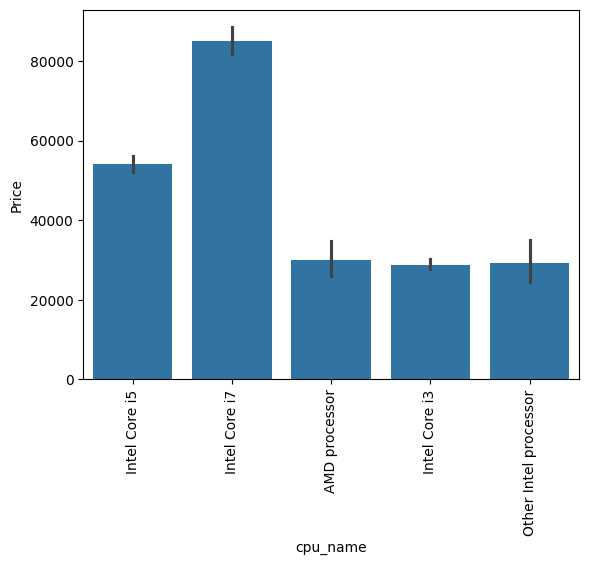

In [420]:
sns.barplot(x=df["cpu_name"],y=df["Price"])
plt.xticks(rotation='vertical')
plt.show()

In [421]:
df["Ram"].value_counts()

Ram
8     619
4     375
16    200
6      41
12     25
2      22
32     17
24      3
64      1
Name: count, dtype: int64

In [422]:
df["Memory"].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [423]:
import pandas as pd

# Clean Memory column
df["Memory"] = (
    df["Memory"].astype(str)
    .str.replace(r"\.0", "", regex=True)
    .str.replace("GB", "", regex=False)
    .str.replace("TB", "000", regex=False)
)

# Split into two layers
split_mem = df["Memory"].str.split("+", n=1, expand=True)
split_mem = split_mem.fillna("0")

first = split_mem[0]
second = split_mem[1]

# Helper function to extract size based on type
def extract_size(text, storage_type):
    if storage_type in text:
        return int("".join(filter(str.isdigit, text)) or 0)
    return 0

# Loop through storage types to avoid repetition
# This directly assigns the sum to df without creating intermediate 'Layer' columns
for stype in ["HDD", "SSD", "Hybrid", "Flash Storage"]:
    df[stype.replace(" ", "_")] = (
        first.apply(lambda x: extract_size(x, stype))
        + second.apply(lambda x: extract_size(x, stype))
    )

# Memory column is no longer needed as we've extracted its features
df.drop(columns=['Memory'], inplace=True)


In [424]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,Hybrid,Flash_Storage
1229,MSI,Gaming,8,Nvidia GeForce GTX 1050,Windows 10,2.20,61218,0,0,141.211998,Intel Core i7,1000,128,0,0
1094,HP,Netbook,4,Intel HD Graphics 520,Windows 7,2.40,85194,0,0,125.367428,Intel Core i5,0,128,0,0
604,Dell,Notebook,4,AMD Radeon R5 M420,Linux,2.18,24775,0,0,100.454670,Intel Core i3,1000,0,0,0
856,Asus,Notebook,4,Intel HD Graphics 505,Windows 10,2.00,23922,0,0,100.454670,Other Intel processor,1000,0,0,0
494,Asus,Gaming,24,Nvidia GeForce GTX 965M,Windows 10,4.33,67612,1,1,127.335675,Intel Core i7,1000,256,0,0


In [425]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,Hybrid,Flash_Storage
357,Dell,Gaming,8,Nvidia GeForce GTX 1050,Windows 10,2.65,53226,0,0,141.211998,Intel Core i5,1000,0,0,0
884,Dell,Notebook,4,Intel HD Graphics,Windows 10,2.20,19660,0,0,100.454670,Other Intel processor,500,0,0,0
1082,Lenovo,2 in 1 Convertible,4,Intel HD Graphics 400,Windows 10,0.69,34433,1,1,224.173809,Other Intel processor,0,0,0,64
1003,HP,Notebook,4,Intel HD Graphics 620,Windows 10,1.64,41505,0,0,111.935204,Intel Core i5,500,0,0,0
1192,HP,Notebook,4,Intel HD Graphics 620,Windows 10,1.86,25840,0,0,100.454670,Intel Core i5,500,0,0,0


In [426]:
df.corr(numeric_only=True)['Price']

Ram              0.743007
Weight           0.210370
Price            1.000000
Touchscreen      0.191226
IPS              0.252207
ppi              0.473487
HDD             -0.096442
SSD              0.670799
Hybrid           0.007989
Flash_Storage   -0.040511
Name: Price, dtype: float64

In [427]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [428]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD
186,Dell,Notebook,16,Nvidia GeForce GTX 1050,Windows 10,2.06,127712,1,0,282.423996,Intel Core i7,0,512
912,Lenovo,Notebook,6,Nvidia GeForce 940MX,Windows 10,2.20,42037,0,0,141.211998,Intel Core i7,0,256
528,Dell,Notebook,4,AMD Radeon R5 M430,Windows 10,2.30,31168,0,0,141.211998,Intel Core i5,500,0
1084,Dell,Notebook,8,Intel HD Graphics 620,Windows 10,2.18,39960,0,0,141.211998,Intel Core i5,0,256
484,Lenovo,Notebook,4,Intel HD Graphics 520,Windows 10,2.30,30103,0,0,100.454670,Intel Core i3,0,128


In [429]:
# extract the gpu brand name
df['GPU_brand'] = df["Gpu"].apply(lambda x: x.split(" ")[0])

In [430]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,GPU_brand
311,Dell,Ultrabook,16,Intel UHD Graphics 620,Windows 10,1.21,133146,1,1,331.264236,Intel Core i7,0,1000,Intel
608,Lenovo,2 in 1 Convertible,8,Intel HD Graphics 630,Windows 10,2.00,69210,1,1,141.211998,Intel Core i7,0,256,Intel
34,Apple,Ultrabook,8,Intel HD Graphics 6000,Mac OS X,1.35,53173,0,0,127.677940,Intel Core i5,0,0,Intel
690,Acer,Notebook,4,Intel HD Graphics 510,Chrome OS,1.45,19980,0,0,111.935204,Other Intel processor,0,0,Intel
354,Toshiba,Notebook,16,Nvidia GeForce 930M,Windows 10,2.40,74751,0,1,141.211998,Intel Core i7,0,512,Nvidia


In [431]:
df = df[df["GPU_brand"] != 'ARM']

<Axes: xlabel='GPU_brand', ylabel='Price'>

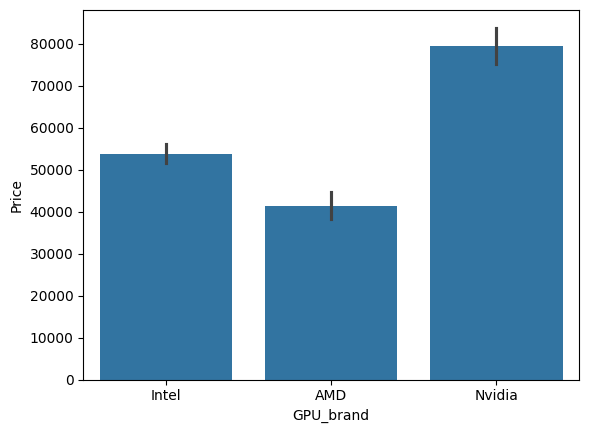

In [432]:
sns.barplot(x=df["GPU_brand"],y=df["Price"])

In [433]:
df.drop(columns=["Gpu"],inplace=True)

C:\Users\piyus\AppData\Local\Temp\ipykernel_3960\1752234203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["Gpu"],inplace=True)


In [434]:
df.sample(5)

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,GPU_brand
841,Dell,Gaming,32,Windows 10,4.42,163723,0,1,127.335675,Intel Core i7,1000,512,Nvidia
466,Acer,Notebook,4,Windows 10,2.20,24988,0,0,100.454670,Intel Core i3,500,0,Nvidia
89,Dell,Ultrabook,8,Windows 10,1.21,87858,0,1,165.632118,Intel Core i7,0,256,Intel
164,Acer,Notebook,4,Windows 10,2.10,18541,0,0,100.454670,Other Intel processor,1000,0,Intel
58,MSI,Gaming,16,Windows 10,2.43,130482,0,0,127.335675,Intel Core i7,2000,256,Nvidia


In [435]:
df["OpSys"].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [436]:
def cat_os(x):
    if x == 'Windows 10' or x == 'Windows 7' or x == 'Windows 10 S':
        return 'Windows'
    elif x == 'macOS' or x=='Mac OS X':
        return 'Mac OS'
    else:
        return 'other/no os/Linux'

In [437]:
df['OS'] = df['OpSys'].apply(cat_os)

C:\Users\piyus\AppData\Local\Temp\ipykernel_3960\3218697124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OS'] = df['OpSys'].apply(cat_os)


In [438]:
df.sample(5)

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,GPU_brand,OS
810,HP,Gaming,12,Windows 10,3.74,93186,0,1,127.335675,Intel Core i7,1000,0,AMD,Windows
712,Dell,Notebook,8,Linux,1.98,38681,0,0,141.211998,Intel Core i5,1000,0,Intel,other/no os/Linux
581,Dell,Notebook,8,Windows 10,1.90,53733,0,0,100.454670,Intel Core i5,500,0,Intel,Windows
5,Acer,Notebook,4,Windows 10,2.10,21312,0,0,100.454670,AMD processor,500,0,AMD,Windows
1225,Asus,Notebook,4,Windows 10,2.65,16463,0,0,100.454670,Other Intel processor,1000,0,Intel,Windows


In [439]:
df.drop(columns=['OpSys'],inplace=True)

C:\Users\piyus\AppData\Local\Temp\ipykernel_3960\3105339334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['OpSys'],inplace=True)


In [440]:
df.sample(5)

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,GPU_brand,OS
722,Lenovo,Ultrabook,8,1.32,79866,0,1,157.350512,Intel Core i5,0,256,Intel,Windows
633,Lenovo,Notebook,4,2.20,30849,0,0,141.211998,Intel Core i3,1000,0,Nvidia,Windows
692,HP,Workstation,8,3.14,101657,0,0,127.335675,Intel Core i7,500,0,Nvidia,Windows
562,HP,Ultrabook,16,1.16,104695,1,1,276.053530,Other Intel processor,0,512,Intel,Windows
322,Asus,Notebook,8,2.00,58288,0,0,157.350512,Intel Core i7,0,256,Intel,Windows


In [441]:
x = df.drop(columns=['Price'])
y = np.log(df["Price"])

In [442]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1041, 12), (261, 12), (1041,), (261,))

In [443]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from xgboost import XGBRegressor

In [444]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

model = LinearRegression()
pipe = Pipeline([
    ('step1',step1),
    ('step2',model)
])
pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8081326602905404
0.2146163794312644
0.07392710557407983


In [445]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

model = Ridge()

pipe = Pipeline([
    ('step1',step1),
    ('step2',model)
])

pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8084893494578448
0.214745631974854
0.07378967208608563


In [446]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

model = Lasso()
pipe = Pipeline([
    ('step1',step1),
    ('step2',model)
])

pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)

print(r2_score(y_test,y_pred))  
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.4793395992979992
0.35887788425441963
0.2006121337233604


In [447]:
model = KNeighborsRegressor(n_neighbors=3)

pipe = Pipeline([
    ('step1',step1),
    ('step2',model)
])

pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.7644805093057571
0.22730656047630596
0.09074642031141056


In [448]:
model = RandomForestRegressor(n_estimators=100,max_depth=15,random_state=3,max_samples=0.5,max_features=0.75)

pipe = Pipeline([
    ('step1',step1),
    ('step2',model)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8645935134790281
0.17450391687660163


In [449]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

step2 = DecisionTreeRegressor(max_depth=8)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8319387272796553
MAE 0.19432494536473124


In [450]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

step2 = ExtraTreesRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15,
                              bootstrap=True)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8611375628091464
MAE 0.17601002777588706


In [451]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

step2 = GradientBoostingRegressor(n_estimators=500)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8739715420913872
MAE 0.16725947414218206


In [452]:
df.shape

(1302, 13)

In [453]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
],remainder='passthrough')

step2 = XGBRegressor(n_estimators=45,max_depth=5,learning_rate=0.5)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8816078410738502
MAE 0.16220133714802112


In [454]:
import pickle
pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

In [2]:
df.sample(5)

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS,ppi,cpu_name,HDD,SSD,GPU_brand,OS
1193,Apple,Ultrabook,8,0.92,61964,0,1,226.415547,Other Intel processor,0,0,Intel,Mac OS
653,MSI,Gaming,8,2.20,63499,0,0,141.211998,Intel Core i7,1000,128,Nvidia,Windows
838,Lenovo,Notebook,4,1.50,17316,0,0,111.935204,Other Intel processor,0,0,Intel,other/no os/Linux
293,Dell,Notebook,8,2.00,97449,0,0,141.211998,Intel Core i7,0,256,Nvidia,Windows
58,MSI,Gaming,16,2.43,130482,0,0,127.335675,Intel Core i7,2000,256,Nvidia,Windows


In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the prepared dataframe
# Assuming df.pkl already exists from previous training
try:
    df = pickle.load(open('./df.pkl', 'rb'))
except FileNotFoundError:
    # If not found, load from CSV and do minimal processing
    df = pd.read_csv('./laptop_data.csv')
    # ... (same preprocessing as in train_model.py) ...
    # (Simplified for this script)
    df.drop(columns=['Unnamed: 0'], inplace=True)
    df['Ram'] = df['Ram'].str.replace('GB', '').astype('int32')
    df['Weight'] = df['Weight'].str.replace('kg', '').astype('float32')
    df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
    df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS Panel' in x else 0)
    new = df['ScreenResolution'].str.split('x', n=1, expand=True)
    df['x_res'] = new[0].str.extract(r'(\d+)').astype('int')
    df['y_res'] = new[1].astype('int')
    df['ppi'] = (((df['x_res']**2) + (df['y_res']**2))**0.5 / df['Inches']).astype('float')
    df.drop(columns=['ScreenResolution', 'Inches', 'x_res', 'y_res'], inplace=True)
    def fetch_processor(text):
        if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3': return text
        else: return 'Other Intel Processor' if text.split()[0] == 'Intel' else 'AMD Processor'
    df['cpu_name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3])).apply(fetch_processor)
    df.drop(columns=['Cpu'], inplace=True)
    # Simplified Memory (already handled in previous turn but for standalone script consistency)
    df['HDD'] = df['Memory'].apply(lambda x: 1000 if '1TB HDD' in x else (500 if '500GB HDD' in x else 0))
    df['SSD'] = df['Memory'].apply(lambda x: 256 if '256GB SSD' in x else (512 if '512GB SSD' in x else (128 if '128GB SSD' in x else 0)))
    df.drop(columns=['Memory'], inplace=True)
    df['GPU_brand'] = df['Gpu'].apply(lambda x:x.split()[0])
    df = df[df['GPU_brand'] != 'ARM']
    df.drop(columns=['Gpu'], inplace=True)
    def cat_os(inp):
        if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S': return 'Windows'
        elif inp == 'macOS' or inp == 'Mac OS X': return 'Mac'
        else: return 'Others/No OS/Linux'
    df['OS'] = df['OpSys'].apply(cat_os)
    df.drop(columns=['OpSys'], inplace=True)

# Training Data
X = df.drop(columns=['Price'])
y = np.log(df['Price'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)

# Pipeline
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 7, 10, 11])
], remainder='passthrough')

# Grid Search Parameters
param_grid = {
    'model__n_estimators': [50, 100, 200, 500],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9]
}

pipe = Pipeline([
    ('step1', step1),
    ('model', XGBRegressor())
])

print("Starting Hyperparameter Tuning...")
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("\nBest Parameters found:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nPerformance of Best Model:")
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

# Update pipe.pkl if improvement is found
# (Usually we'd save it here)
pickle.dump(best_model, open('./pipe_optimized.pkl', 'wb'))
print("\nOptimized model saved as pipe_optimized.pkl")



Starting Hyperparameter Tuning...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best Parameters found:
{'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}

Performance of Best Model:
R2 score: 0.8888986409258411
MAE: 0.1503140805970185

Optimized model saved as pipe_optimized.pkl


In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load Data
df = pd.read_csv('./laptop_data.csv')

# 2. Advanced Feature Engineering
df.drop(columns=['Unnamed: 0'], inplace=True)
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int32')
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float32')

# CPU GHz Extraction
df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+(?:\.\d+)?)\s*GHz').astype(float)

# CPU Brand and Series
def fetch_cpu_series(text):
    words = text.split()
    if 'Core' in words:
        # e.g., "Intel Core i7 7700HQ" -> "Core i7"
        return " ".join(words[1:3])
    else:
        return words[0] # e.g., "AMD" or "Samsung"

df['Cpu_Series'] = df['Cpu'].apply(fetch_cpu_series)

# GPU Model (remove brand)
df['Gpu_Model'] = df['Gpu'].apply(lambda x: " ".join(x.split()[1:]))

# Screen Specs
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS Panel' in x else 0)
res = df['ScreenResolution'].str.split('x', n=1, expand=True)
df['x_res'] = res[0].str.extract(r'(\d+)').astype('int')
df['y_res'] = res[1].astype('int')
df['ppi'] = (((df['x_res']**2) + (df['y_res']**2))**0.5 / df['Inches']).astype('float')

# Memory
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True).str.replace('GB', '').str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)
df["first"] = new[0].str.extract(r'(\d+)').fillna(0).astype(int)
df["second"] = new[1].str.extract(r'(\d+)').fillna(0).astype(int)
df["HDD"] = df.apply(lambda x: x['first'] if 'HDD' in str(new[0][x.name]) else (x['second'] if 'HDD' in str(new[1][x.name]) else 0), axis=1)
df["SSD"] = df.apply(lambda x: x['first'] if 'SSD' in str(new[0][x.name]) else (x['second'] if 'SSD' in str(new[1][x.name]) else 0), axis=1)

# OS
def cat_os(inp):
    if 'Windows' in inp: return 'Windows'
    elif 'Mac' in inp or 'macOS' in inp: return 'Mac'
    else: return 'Others'
df['OS'] = df['OpSys'].apply(cat_os)

# Drop raw columns
cols_to_drop = ['Cpu', 'Gpu', 'ScreenResolution', 'Inches', 'x_res', 'y_res', 'Memory', 'OpSys', 'first', 'second']
df.drop(columns=cols_to_drop, inplace=True)

# 3. Model Stacking & Training
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Column indices for OHE: Company(0), TypeName(1), Cpu_Series(5), Gpu_Model(6), OS(12)
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), [0, 1, 5, 6, 12])
], remainder='passthrough')

# Base Models
estimators = [
    ('xgb', XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, subsample=0.8)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=15, max_features=0.75, random_state=3))
]

# Stacking Model
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=XGBRegressor(n_estimators=50, learning_rate=0.1),
    cv=5
)

pipe = Pipeline([
    ('step1', step1),
    ('scaler', RobustScaler()), # Handling outliers
    ('model', stack_model)
])

print("Training Stacking Ensemble with Cross-Validation...")
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print("\n--- PERFORMANCE ---")
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

# Save
pickle.dump(df, open('./df_ultimate.pkl', 'wb'))
pickle.dump(pipe, open('./pipe_ultimate.pkl', 'wb'))
print("\nUltimate model saved as pipe_ultimate.pkl")



Training Stacking Ensemble with Cross-Validation...

--- PERFORMANCE ---
R2 score: 0.8825577402802666
MAE: 0.1525305502565416

Ultimate model saved as pipe_ultimate.pkl


c:\Users\piyus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
